In [54]:
#%%
# --- modules ---
import pandas as pd 
import os, sys
from pathlib import Path
import rootutils
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# --- hard coded paths ---
ROOT_PATH = rootutils.find_root(search_from=Path.cwd(), indicator=".git")
sys.path.append(str(ROOT_PATH))
ROOTDIR_DATA = os.path.join(ROOT_PATH, "Data", "processed")
sys.path.append(ROOTDIR_DATA)

# --- hard coded constants ---
from Scripts.constants import (
    CATCHMENT_AREA_DEMER, #area in km2
)

#%% code to load the data
# --- load the excel sheet with data ---
data_path=os.path.join(ROOTDIR_DATA, "Practicum_2_Eenheidshydrogram_Demer.csv")
df = pd.read_csv(data_path, index_col=None)
df['Datum_tijd'] = pd.to_datetime(df["Datum_tijd"],format='%d/%m/%Y %H:%M')
print(df.head())

           Datum_tijd  Q (m3/s)  P (mm/h)
0 2010-08-04 14:00:00      5.97       1.5
1 2010-08-04 15:00:00      6.09       0.7
2 2010-08-04 16:00:00      5.99       0.0
3 2010-08-04 17:00:00      5.92       0.0
4 2010-08-04 18:00:00      5.88       0.0


In [55]:
# --- convert the precipitation to m3/h and the discharge to m3/h ---
df["P (m3/h)"]=df["P (mm/h)"]*CATCHMENT_AREA_DEMER*1000
df["Q (m3/h)"]=df["Q (m3/s)"]*3600
print(df.head())

           Datum_tijd  Q (m3/s)  P (mm/h)      P (m3/h)  Q (m3/h)
0 2010-08-04 14:00:00      5.97       1.5  2.860994e+06   21492.0
1 2010-08-04 15:00:00      6.09       0.7  1.335131e+06   21924.0
2 2010-08-04 16:00:00      5.99       0.0  0.000000e+00   21564.0
3 2010-08-04 17:00:00      5.92       0.0  0.000000e+00   21312.0
4 2010-08-04 18:00:00      5.88       0.0  0.000000e+00   21168.0


In [56]:
#%% Question 1: make hydrographs for both 2020 and 2023
def PlotHydrographYear(
        df: pd.DataFrame,
        jaar: float
    ) -> plt.figure:
    """
    Function to plot the hydrograph of a given event.
    """
    df_jaar = df[df['Datum_tijd'].dt.year == jaar ].reset_index(drop=True)

    #---make the plot---
    fig, ax = plt.subplots(figsize=(12, 5))

    #discharge at the bottom
    ax.plot(
        df_jaar["Datum_tijd"],
        df_jaar["Q (m3/h)"],
        color="tab:blue",
        lw=2,
    )
    ax.set_ylabel("Discharge (m$^3$ h$^{-1}$)", color="tab:blue", fontsize=18)
    ax.tick_params(axis="y", labelcolor="tab:blue")
    ax.spines["top"].set_visible(False)

    #precipitation  at the top
    ax2 = ax.twinx()
    ax2.bar(
        df_jaar["Datum_tijd"],
        df_jaar["P (m3/h)"],
        width=0.9,
        color="tab:orange",
        alpha=0.6,
    )
    ax2.invert_yaxis()
    ax2.set_ylim(df_jaar["P (m3/h)"].max() * 1.1, 0) #0 at the top

    # Move ticks and label to the top
    ax2.xaxis.set_visible(False)
    ax2.yaxis.set_label_position("right")
    ax2.yaxis.tick_right()

    ax2.set_ylabel("Precipitation (m$^3$ h$^{-1}$)", color="tab:orange", fontsize=18)
    ax2.tick_params(axis="y", labelcolor="tab:orange")

    # Cosmetics
    ax.grid(axis="y", alpha=0.3)
    ax.set_xlabel("Date [-]", fontsize=18)
    fig.tight_layout()

    ax.tick_params(axis="both", labelsize=15)
    ax2.tick_params(axis="y", labelsize=15)

    plt.show()
    return fig

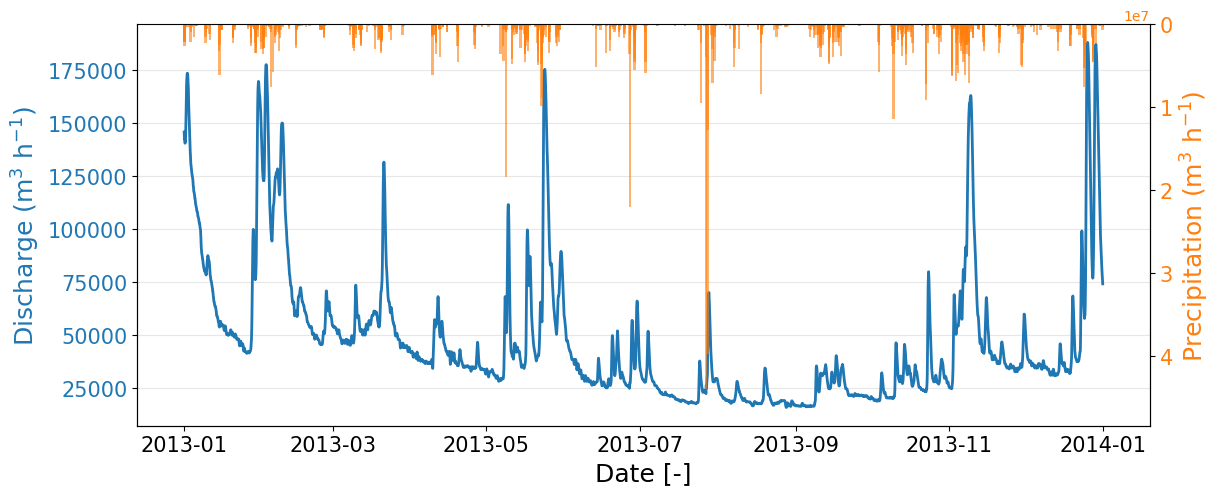

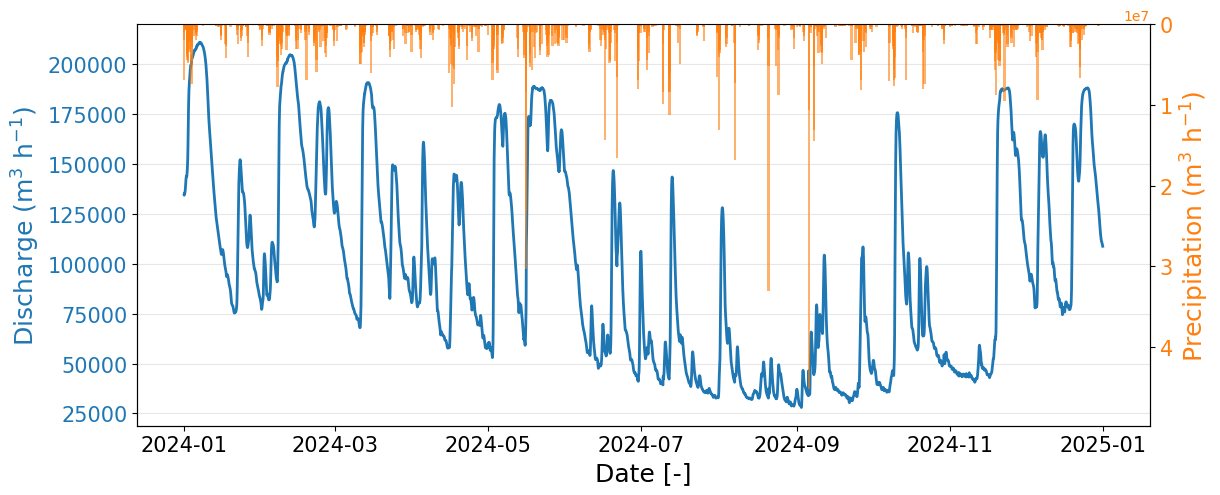

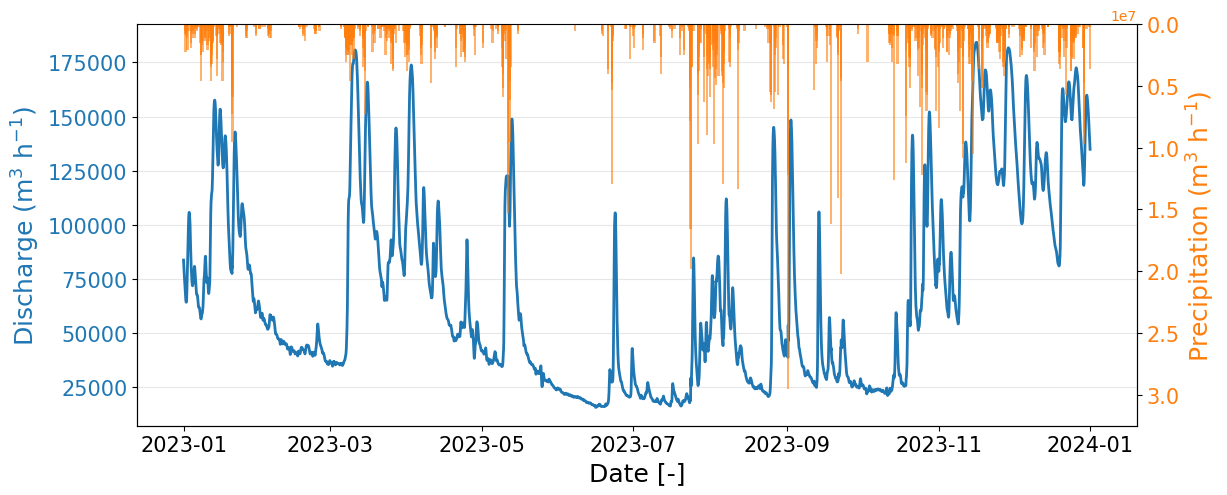

In [57]:
fig_2013 = PlotHydrographYear(df, 2013)
fig_2024 = PlotHydrographYear(df, 2024)
fig_2023 = PlotHydrographYear(df, 2023)

In [59]:
#%% Question 2: Make a figure of discharge and P for a specific event
def PlotHydrographEvent(
    date_ini:pd.Timestamp = pd.to_datetime("2013-08-18 02:00:00.000"),
    date_end:pd.Timestamp = pd.to_datetime("2013-08-23 06:00:00.000"),
    df:pd.DataFrame = df.copy()
    ) -> tuple[plt.figure, pd.DataFrame, float]:
    """
    Function to plot the hydrograph of a given event. 
    Note that also the output for the different questions is printed in the console.
    """
    print((date_end-date_ini).total_seconds()/3600, "h of data")
    # --- take the subset ---
    df_sub = df.loc[(df["Datum_tijd"] >= date_ini) & 
                (df["Datum_tijd"] <= date_end)].copy()
    print(df_sub.head())

    # --- plot the hydrograph ---
    fig,ax=plt.subplots(figsize=(10,6))
    ax.plot(df_sub["Datum_tijd"], df_sub["Q (m3/h)"], color="tab:blue", lw=2)
    ax.set_xlabel("date [-]", fontsize=15)
    ax.set_ylabel("Q [m3/h]", color="tab:blue", fontsize=15)
    ax.tick_params(axis="y", labelcolor="tab:blue")

    ax2=ax.twinx()
    ax2.bar(df_sub["Datum_tijd"], df_sub["P (m3/h)"], color="#A02FCC", width=0.015)
    ax2.set_ylabel("P [m3/h]",color="#A02FCC", fontsize=15)
    ax2.tick_params(axis="y", labelcolor="#A02FCC")

    for ax in [ax, ax2]:
        ax.tick_params(axis="both", labelsize=12)
    fig.tight_layout()
    plt.show()

    #calculate after how many hours the discharge is maximal
    Tstart_P = df_sub.loc[df_sub["P (m3/h)"] != 0,
                        "Datum_tijd"].iloc[0]

    Tmax_Q = df_sub.loc[df_sub["Q (m3/h)"]==np.max(df_sub["Q (m3/h)"]), 
                        "Datum_tijd"].iloc[0]

    print(f"The maximum discharge appears after {round((Tmax_Q-Tstart_P).total_seconds()/3600)} hours")

    #now compute the base flow
    Q_base = np.floor(df_sub["Q (m3/h)"].min())
    print(f"The baseflow is {Q_base} m3/h (Q_base)")

    #calculate the direct runoff
    df_sub["Q_direct (m3/h)"] = df_sub["Q (m3/h)"]-Q_base
    print(f"The total direct runoff for this event is {df_sub['Q_direct (m3/h)'].sum()} m3/h")

    return fig, df_sub, Q_base

124.0 h of data
               Datum_tijd  Q (m3/s)  P (mm/h)  P (m3/h)  Q (m3/h)
26628 2013-08-18 02:00:00      4.97       0.0       0.0   17892.0
26629 2013-08-18 03:00:00      4.97       0.0       0.0   17892.0
26630 2013-08-18 04:00:00      4.93       0.0       0.0   17748.0
26631 2013-08-18 05:00:00      4.94       0.0       0.0   17784.0
26632 2013-08-18 06:00:00      4.94       0.0       0.0   17784.0


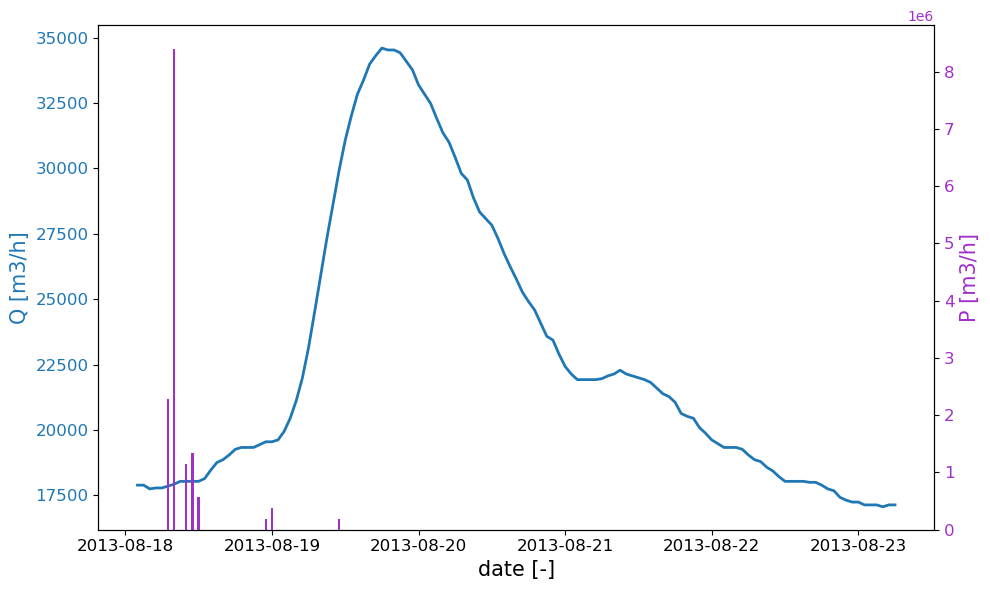

The maximum discharge appears after 35 hours
The baseflow is 17064.0 m3/h (Q_base)
The total direct runoff for this event is 708912.0 m3/h
               Datum_tijd  Q (m3/s)  P (mm/h)  P (m3/h)  Q (m3/h)  \
26628 2013-08-18 02:00:00      4.97       0.0       0.0   17892.0   
26629 2013-08-18 03:00:00      4.97       0.0       0.0   17892.0   
26630 2013-08-18 04:00:00      4.93       0.0       0.0   17748.0   
26631 2013-08-18 05:00:00      4.94       0.0       0.0   17784.0   
26632 2013-08-18 06:00:00      4.94       0.0       0.0   17784.0   

       Q_direct (m3/h)  
26628            828.0  
26629            828.0  
26630            684.0  
26631            720.0  
26632            720.0  


In [60]:
Hydrograph, df_2013, Q_base = PlotHydrographEvent()
print(df_2013.head(5))

In [61]:
#%% Question 3 $\phi$-method
# calculate the discharge in mm of the direct discharge
df_2013["Q_direct (mm/h)"] = df_2013["Q_direct (m3/h)"]/(CATCHMENT_AREA_DEMER*1000)

#calculate the effective precipitation -> equation 6.18
print(f"The netto effective precipitation is {df_2013['Q_direct (mm/h)'].sum()}")

#calculate the phi index

#get the rainevent leading to the hydrograph -> this is the first event of the subset (VISUAL INSPECTION)
P_rainevent = df_2013.loc[\
    (df_2013["Datum_tijd"] <= pd.to_datetime("2013-08-19")) & 
    (df_2013["P (mm/h)"] > 0)
    ].copy()

#calculate phi 
duration_rainevent = (P_rainevent["Datum_tijd"].max() - P_rainevent["Datum_tijd"].min()).total_seconds()/3600
phi = -(df_2013["Q_direct (mm/h)"].sum() - P_rainevent["P (mm/h)"].sum()) / duration_rainevent
print(f"The value for phi is {phi} mm/h")

#calculate the adjustment for the phi-index
adj = 0
P_rainevent["Peff (mm/h)"] = np.where(P_rainevent["P (mm/h)"]-(phi+adj) < 0,
                               0,
                               P_rainevent["P (mm/h)"]-(phi+adj))

diff=np.abs(df_2013["Q_direct (mm/h)"].sum()-P_rainevent["Peff (mm/h)"].sum())
while diff > 0.01:

    adj=adj+0.001 #add increment to the adjustment

    P_rainevent["Peff (mm/h)"] = np.where(P_rainevent["P (mm/h)"]-(phi+adj) < 0,
                                   0,
                                    P_rainevent["P (mm/h)"]-(phi+adj)
                                    )
    
    diff = np.abs(df_2013["Q_direct (mm/h)"].sum() - P_rainevent["Peff (mm/h)"].sum())

phi = phi + adj
print(f"The phi-index needs to be adjusted with: {round(adj,2)}")
print(f"The final phi is {phi}")
print("\nBelangrijk! Hoelang er effectieve neerslag is, dit bepaalt de tijdstap van je eenheidshydrogram:")
print(P_rainevent[['Datum_tijd', 'P (mm/h)', 'Peff (mm/h)']].to_string(index=False))

The netto effective precipitation is 0.3716777897232354
The value for phi is 0.41931307119275085 mm/h
The phi-index needs to be adjusted with: 3.6
The final phi is 4.019313071192466

Belangrijk! Hoelang er effectieve neerslag is, dit bepaalt de tijdstap van je eenheidshydrogram:
         Datum_tijd  P (mm/h)  Peff (mm/h)
2013-08-18 07:00:00       1.2     0.000000
2013-08-18 08:00:00       4.4     0.380687
2013-08-18 10:00:00       0.6     0.000000
2013-08-18 11:00:00       0.7     0.000000
2013-08-18 12:00:00       0.3     0.000000
2013-08-18 23:00:00       0.1     0.000000
2013-08-19 00:00:00       0.2     0.000000


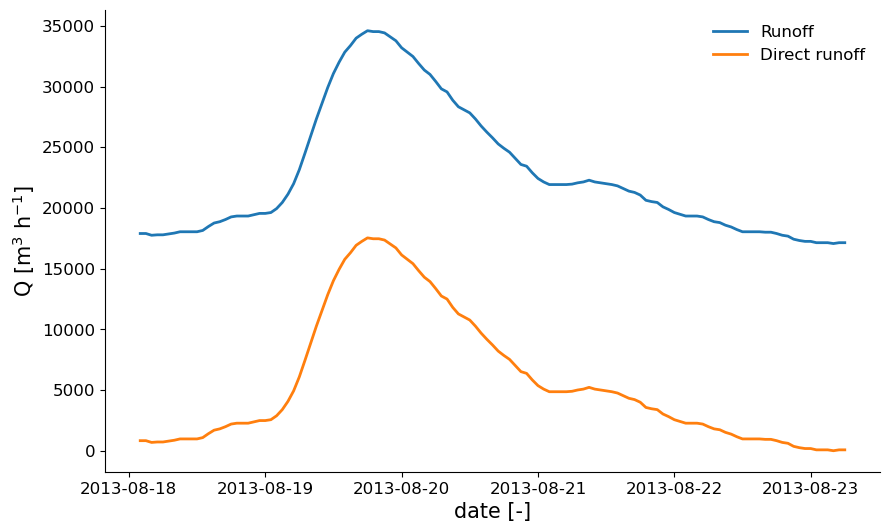

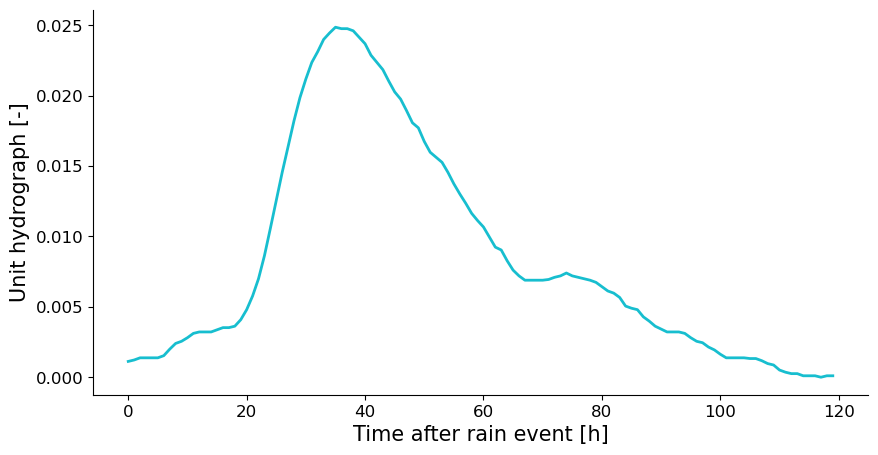

In [70]:
#%% Question 4: Plot the discharge and get the unit hydrograph
# --- plot the total and direct runoff ---
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(df_2013["Datum_tijd"], df_2013["Q (m3/h)"], color="tab:blue", label="Runoff", lw=2)
ax.plot(df_2013["Datum_tijd"], df_2013["Q_direct (m3/h)"], color="tab:orange", label="Direct runoff", lw=2)
ax.legend(loc="best", frameon=False, fontsize=12)

ax.set_xlabel("date [-]", fontsize=15)
ax.set_ylabel("Q [m$^3$ h$^{-1}$]", fontsize=15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=12)

# --- plot the UH ---
# get the unit hydrograph
begin_hydrograph = df_2013[df_2013["P (mm/h)"] > 0].index[0]
df_UH = df_2013.loc[begin_hydrograph:,:].copy().reset_index(drop=True)
df_UH["UH"] = df_UH["Q_direct (m3/h)"] / df_UH["Q_direct (m3/h)"].sum()
df_UH["time_after_rain"] = (df_UH["Datum_tijd"] - df_UH.loc[0,"Datum_tijd"]).dt.total_seconds()/3600

# plot the UH
fig,ax = plt.subplots(figsize=(10,5))
ax.plot(df_UH["time_after_rain"], df_UH["UH"], color="tab:cyan", lw=2)
ax.set_ylabel("Unit hydrograph [-]", fontsize=15)
ax.set_xlabel("Time after rain event [h]", fontsize=15)
ax.tick_params(axis="both", labelsize=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

In [78]:
#tstart = pd.to_datetime("2023-10-14 01:00:00")
#tend = pd.to_datetime("2023-10-16 13:00:00")
def ModeleerAfvoer(
    date_ini:pd.Timestamp = pd.to_datetime("2024-07-09 12:00:00.000"),
    date_end:pd.Timestamp = pd.to_datetime("2024-07-14 16:00:00.000"),
    df:pd.DataFrame = df.copy(),
    df_UH:pd.DataFrame = df_UH.copy(),
    phi: float=phi,
    Q_base: float=Q_base) -> pd.DataFrame:

    # --- calculate the discharge ---
    df_q5=df.loc[(df["Datum_tijd"] >= date_ini) & (df["Datum_tijd"] <= date_end)].copy()

    phi_m3 = phi*(CATCHMENT_AREA_DEMER*1000)

    # calculate the effective precipitation for the hydrograph
    effective_rainevent = df_q5[df_q5["P (m3/h)"] > phi_m3].copy().reset_index(drop=True)
    effective_rainevent['Peff (m3/h)'] = effective_rainevent['P (m3/h)'] - phi_m3

    def simoutput (effective_rainevent, i):
        effectieve_neerslag = effective_rainevent['Peff (m3/h)'].iloc[i]
        afvoer = effectieve_neerslag*df_UH['UH']

        starttijd = effective_rainevent["Datum_tijd"].iloc[i]
        tijd = starttijd + pd.to_timedelta(df_UH["time_after_rain"], unit="h")

        df_sim = pd.DataFrame({"Datum_tijd" : tijd, "Directe Afvoer Simulatie (m3/h)" : afvoer})
        return df_sim

    sim = pd.concat([simoutput(effective_rainevent, i) for i in range(effective_rainevent.shape[0])])

    if effective_rainevent.shape[0] > 0:
        sim_df = sim.groupby(['Datum_tijd'])['Directe Afvoer Simulatie (m3/h)'].sum().reset_index()
    else:
        sim_df = sim

    sim_df['Afvoer Simulatie (m3/h)'] = sim_df['Directe Afvoer Simulatie (m3/h)'] + Q_base
    data = pd.merge(sim_df, df[['Datum_tijd', 'Q (m3/h)', 'P (mm/h)']], on=['Datum_tijd'], how="inner")
    data = data.rename(columns={'Q (m3/h)' : 'Afvoer Observatie (m3/h)'})
    print(data.head(5))
    return(data)

In [79]:
data = ModeleerAfvoer()

           Datum_tijd  Directe Afvoer Simulatie (m3/h)  \
0 2024-07-09 18:00:00                       815.545960   
1 2024-07-09 19:00:00                      3419.073203   
2 2024-07-09 20:00:00                      3760.228261   
3 2024-07-09 21:00:00                      4105.144630   
4 2024-07-09 22:00:00                      4105.144630   

   Afvoer Simulatie (m3/h)  Afvoer Observatie (m3/h)  P (mm/h)  
0             17879.545960                   39348.0       4.4  
1             20483.073203                   41328.0       5.2  
2             20824.228261                   43416.0       0.3  
3             21169.144630                   42660.0       0.0  
4             21169.144630                   42444.0       0.0  


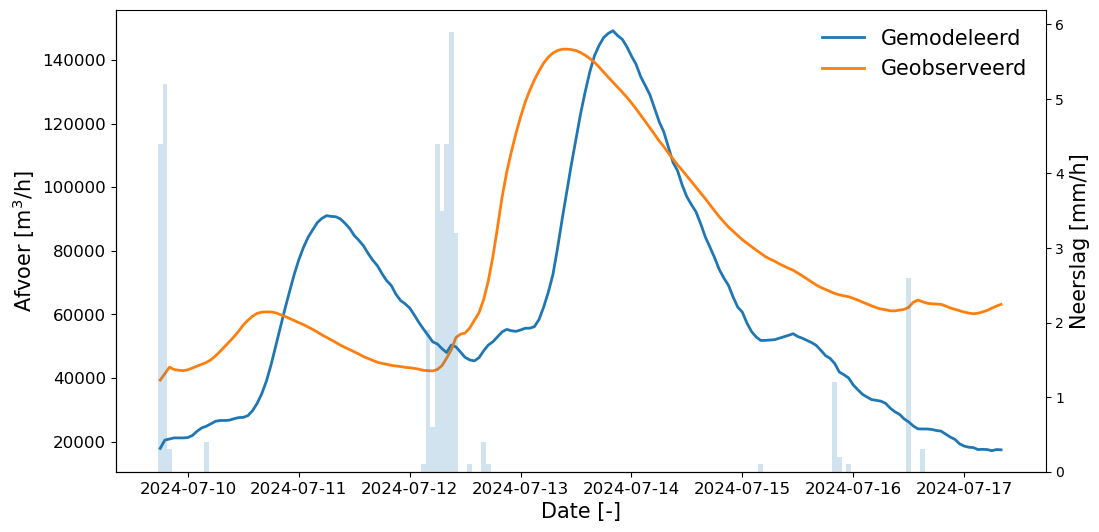

In [80]:
fig, ax=plt.subplots(figsize=(12,6))
ax2 = ax.twinx()
ax.plot(data["Datum_tijd"], data["Afvoer Simulatie (m3/h)"],color="tab:blue", label="Gemodeleerd", lw=2)
ax.plot(data["Datum_tijd"], data["Afvoer Observatie (m3/h)"], color="tab:orange", label="Geobserveerd", lw=2)
ax2.bar(data["Datum_tijd"], data["P (mm/h)"], 1/24, color="tab:blue", alpha=0.2, label="Neerslag", lw=2, zorder=1)
ax.set_xlabel("Date [-]", fontsize=15)
ax.set_ylabel("Afvoer [m$^3$/h]", fontsize=15)
ax2.set_ylabel("Neerslag [mm/h]", fontsize=15)

ax.legend(fontsize=15, frameon=False, loc="best")

ax.tick_params(axis="both", labelsize=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.show()

#calculate the bias and RMSE
data=data.dropna()

In [81]:
print(f"The bias is {np.mean(data['Afvoer Simulatie (m3/h)']-data["Afvoer Observatie (m3/h)"]):.2f} m³/h")
print(f"The RMSE is {root_mean_squared_error(data['Afvoer Simulatie (m3/h)'],data["Afvoer Observatie (m3/h)"]):.2f} m³/h")
print(f"The correlation is {np.corrcoef(data['Afvoer Simulatie (m3/h)'], data["Afvoer Observatie (m3/h)"])[1,0]:.3f}")

The bias is -14702.61 m³/h
The RMSE is 30812.54 m³/h
The correlation is 0.670


In [82]:
tstart = pd.to_datetime("2023-10-14 01:00:00")
tend = pd.to_datetime("2023-10-16 13:00:00")
data = ModeleerAfvoer(tstart, tend)

           Datum_tijd  Directe Afvoer Simulatie (m3/h)  \
0 2023-10-14 01:00:00                      5528.607998   
1 2023-10-14 02:00:00                      6031.208725   
2 2023-10-14 03:00:00                      6785.109815   
3 2023-10-14 04:00:00                      6785.109815   
4 2023-10-14 05:00:00                      6785.109815   

   Afvoer Simulatie (m3/h)  Afvoer Observatie (m3/h)  P (mm/h)  
0             22592.607998                   29124.0       6.6  
1             23095.208725                   29880.0       0.5  
2             23849.109815                   30564.0       0.0  
3             23849.109815                   30672.0       0.0  
4             23849.109815                   30348.0       0.0  


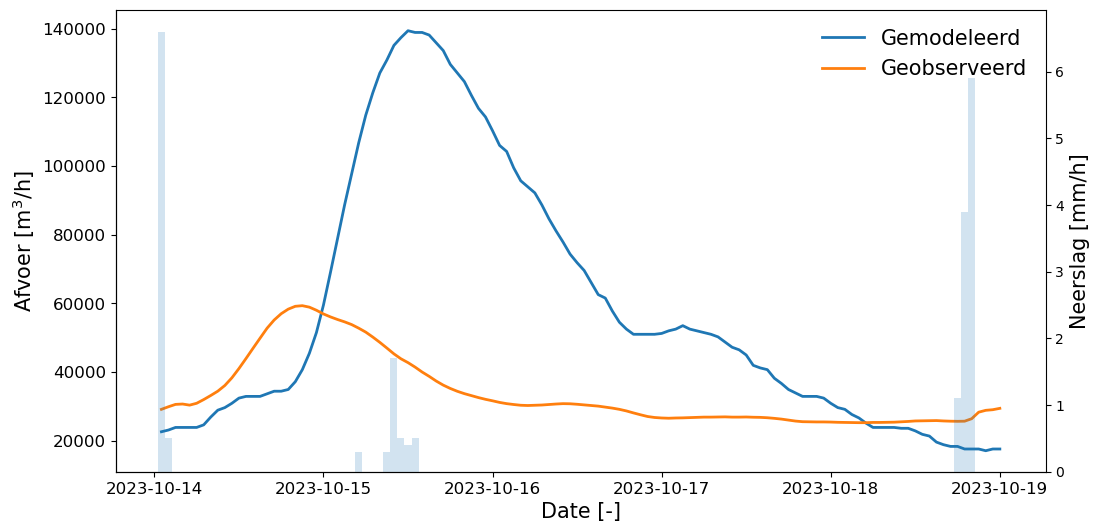

In [83]:
fig, ax=plt.subplots(figsize=(12,6))
ax2 = ax.twinx()
ax.plot(data["Datum_tijd"], data["Afvoer Simulatie (m3/h)"],color="tab:blue", label="Gemodeleerd", lw=2)
ax.plot(data["Datum_tijd"], data["Afvoer Observatie (m3/h)"], color="tab:orange", label="Geobserveerd", lw=2)
ax2.bar(data["Datum_tijd"], data["P (mm/h)"], 1/24, color="tab:blue", alpha=0.2, label="Neerslag", lw=2, zorder=1)
ax.set_xlabel("Date [-]", fontsize=15)
ax.set_ylabel("Afvoer [m$^3$/h]", fontsize=15)
ax2.set_ylabel("Neerslag [mm/h]", fontsize=15)

ax.legend(fontsize=15, frameon=False, loc="best")

ax.tick_params(axis="both", labelsize=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.show()

#calculate the bias and RMSE
data=data.dropna()

In [84]:
print(f"The bias is {np.mean(data['Afvoer Simulatie (m3/h)']-data["Afvoer Observatie (m3/h)"]):.2f} m³/h")
print(f"The RMSE is {root_mean_squared_error(data['Afvoer Simulatie (m3/h)'],data["Afvoer Observatie (m3/h)"]):.2f} m³/h")
print(f"The correlation is {np.corrcoef(data['Afvoer Simulatie (m3/h)'], data["Afvoer Observatie (m3/h)"])[1,0]:.3f}")

The bias is 24318.40 m³/h
The RMSE is 43056.95 m³/h
The correlation is 0.337
